# New MeSH medical terms as a held-out check set: `data.py` demo

This notebook runs **`data.py`**, the script that standardises the **held-out MeSH confirmation population** into the pipeline's `exp_sel_data_out` schema (`full_data_out.json`).

**What the dataset is.** It has 191 new biomedical concepts. Each one is a MeSH descriptor established between 2006 and 2016 (the window was widened to 2004-2005 and 2017-2018), and each one passed three checks:
1. a Nentidis-style provenance filter, which drops parenthetical-prior-year, promoted-term and renamed descriptors;
2. a PubMed `[tiab]` novelty pre-screen;
3. the main corpus's final rule on OpenAlex counts. With `F` = the first year with ≥5 papers (2005-2016), the concept needs 20-300 papers in `F..F+2` and ≤8,000 papers in total over 2000-2024.

A concept's identity and synonyms come only from MeSH preferred-concept terms.

**What `data.py` does.** It reads the prepared source tables in `temp/datasets/` and writes one schema example per row. The input and output are JSON strings, and metadata goes into flat `metadata_*` fields:

| dataset | 1 example per | `input` | `output` |
|---|---|---|---|
| `heldout_mesh_concepts` | concept | concept identity (descriptor UI, preferred term, surface forms, acronyms, tree numbers, `F`, …) | yearly counts for 2000-2024 (text match, MeSH-indexed, final rule), retrieval counts, `final_rule_basis` |
| `mesh_synonym_pairs` | term pair | `{"term_a","term_b"}` | `"1"` synonym / `"0"` hard negative |

**What the demo runs on.** It uses a curated subset, `mini_demo_data.json`: 100 of the 191 concepts, stratified by MeSH branch group × `final_rule_basis`. The subset is in the same raw row format as `temp/datasets/heldout_mesh_concepts.json`, so only the `heldout_mesh_concepts` builder runs here. The `mesh_synonym_pairs` builder is shown unchanged. It needs the 7 MB pairs table from the original workspace.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# data.py itself only uses the Python standard library (gzip, json, sys, pathlib).
# numpy, pandas, matplotlib (for the results/visualisation cells) are pre-installed on Colab, so install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

import gzip
import json
import sys
from pathlib import Path

# extra imports for the notebook's results / visualisation cells
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_YczZzZ0_9kfq/round-1/dataset-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print(f'{len(data["heldout_mesh_concepts"])} concept rows in the demo subset (of {data["metadata"]["n_concepts_full"]} in the full population)')

Curated demo subset of the held-out MeSH confirmation population: the two source tables data.py reads from temp/datasets/ (60 of 191 concepts stratified by MeSH branch group and final-rule basis; 40 held-out synonym/hard-negative pairs across all pair types) plus 10 raw concept-work rows from works/works_part_XX.jsonl.gz.
60 concept rows in the demo subset (of 191 in the full population)


## Configuration

These are the tunable parameters. The original script has none of its own. It always processes every row of both source tables.
- `MAX_CONCEPTS` caps how many concept rows from the demo subset get processed. Set it to `None` to use all 100. The original run used all 191 rows of `temp/datasets/heldout_mesh_concepts.json`.
- `DATASETS` lists the builders to run. The original value is `["heldout_mesh_concepts", "mesh_synonym_pairs"]`. The pairs builder reads `temp/datasets/mesh_synonym_pairs.json` (23,097 pairs), which the demo subset doesn't include.
- `ROOT` is the output directory, taken from `ROOT = Path(__file__).resolve().parent` in the script.

In [5]:
MAX_CONCEPTS = 100          # original: all 191 concepts (full temp/datasets/heldout_mesh_concepts.json); demo subset has 100
DATASETS = ["heldout_mesh_concepts"]   # original: ["heldout_mesh_concepts", "mesh_synonym_pairs"]

ROOT = Path.cwd()                      # original: Path(__file__).resolve().parent
SRC = ROOT / "temp" / "datasets"       # original source dir (only the unused pairs builder still reads from it)

## Helpers: compact JSON and flat metadata

The `exp_sel_data_out` schema needs `input`/`output` as **strings** and metadata as **flat** `metadata_*` fields. `dumps` serialises compactly. `flat_metadata` flattens one nesting level: for example, the nested `pubmed_prescreen` dict becomes `metadata_pubmed_prescreen_F_pubmed`, and so on.

In [6]:
def dumps(o) -> str:
    return json.dumps(o, ensure_ascii=False, separators=(",", ":"))


def flat_metadata(meta: dict, prefix: str = "metadata_") -> dict:
    """Flatten one nesting level into metadata_<key> / metadata_<key>_<sub> fields (schema wants flat fields)."""
    out = {}
    for k, v in meta.items():
        if isinstance(v, dict):
            for k2, v2 in v.items():
                out[f"{prefix}{k}_{k2}"] = v2
        else:
            out[f"{prefix}{k}"] = v
    return out

## Builder 1: `heldout_mesh_concepts` (1 example per concept)

Each source row already has `input` (the concept identity), `output` (the yearly incidence and retrieval results), `metadata_fold` (always `heldout_mesh`) and a nested `metadata` dict. The builder does three things:
- serialises input and output;
- flattens the metadata;
- adds convenience fields: the row index, the concept id, the preferred term, `F`, the task type (`emergence_trajectory`) and the sorted input/output field names.

**Only change from `data.py`:** the rows come from the loaded demo `data`, capped at `MAX_CONCEPTS`, not from `SRC / "heldout_mesh_concepts.json"`. As a result, `metadata_row_index` is the position in the demo subset. The original index is kept in `data["metadata"]["source_row_indices"]`.

In [7]:
def concepts() -> list[dict]:
    # original: rows = json.loads((SRC / "heldout_mesh_concepts.json").read_text())
    rows = data["heldout_mesh_concepts"][:MAX_CONCEPTS]
    ex = []
    for i, c in enumerate(rows):
        e = {"input": dumps(c["input"]), "output": dumps(c["output"]), "metadata_fold": c["metadata_fold"]}
        e.update(flat_metadata(c["metadata"]))
        e.update({"metadata_row_index": i, "metadata_concept_id": c["input"]["concept_id"],
                  "metadata_preferred_term": c["input"]["preferred_term"], "metadata_F": c["input"]["F"],
                  "metadata_task_type": "emergence_trajectory",
                  "metadata_input_fields": sorted(c["input"]), "metadata_output_fields": sorted(c["output"])})
        ex.append(e)
    return ex

## Builder 2: `mesh_synonym_pairs` (1 example per term pair), unchanged

This builder covers all 3,430 provenance-filtered 2006-2016 descriptors. There are 9,477 positive synonym/acronym pairs (label `1`) and 13,620 hard negatives (label `0`): narrower or related concepts and sibling descriptors. `metadata_fold` records whether a pair touches the held-out population (`heldout_mesh`), the main working list (`working_list`) or neither (`train_eligible`). A model trained on synonym matching can then avoid leaking the held-out concepts.

This cell only defines the function, exactly as in `data.py`. It isn't called here because `"mesh_synonym_pairs"` isn't in the demo `DATASETS`, and its source file isn't part of the demo data.

In [8]:
def pairs() -> list[dict]:
    d = json.loads((SRC / "mesh_synonym_pairs.json").read_text())
    ex = []
    for i, p in enumerate(d["pairs"]):
        fold = "heldout_mesh" if p["in_heldout_population"] else ("working_list" if p["in_working_list"] else "train_eligible")
        ex.append({"input": dumps({"term_a": p["term_a"], "term_b": p["term_b"]}), "output": str(p["label"]),
                   "metadata_fold": fold, "metadata_pair_type": p["pair_type"],
                   "metadata_descriptor_ui": p["descriptor_ui"], "metadata_descriptor_ui_b": p["descriptor_ui_b"],
                   "metadata_orig_a": p["orig_a"], "metadata_orig_b": p["orig_b"],
                   "metadata_in_heldout_population": p["in_heldout_population"],
                   "metadata_in_working_list": p["in_working_list"], "metadata_task_type": "classification",
                   "metadata_n_classes": 2, "metadata_row_index": i})
    return ex

## Works sample, truncation and the builder registry

`works_sample(n)` turns the first `n` (concept, work) rows of `works/works_part_01.jsonl.gz` into schema examples, which the script saves as `mini_works.json` and `preview_works.json`. The OpenAlex work record becomes the `input`. The concept-assignment fields (`match_route`, `verified_text_match`, …) become the `output`. The works themselves ship separately as gzip JSONL parts. `truncate` shortens long strings for the preview files. `BUILDERS` maps each dataset name to its builder.

In [9]:
def works_sample(n: int) -> list[dict]:
    """First n concept-work rows (works/works_part_01.jsonl.gz) as schema examples, for mini/preview_works.json.
    The works themselves ship as gzip JSONL parts (one row per (concept, work)), not in full_data_out.json."""
    assign = ("concept_id", "match_route", "verified_text_match", "match_field", "matched_forms",
              "descriptor_indexed_openalex", "descriptor_indexed_pubmed")
    ex = []
    with gzip.open(ROOT / "works" / "works_part_01.jsonl.gz", "rt", encoding="utf-8") as fh:
        for line in fh:
            w = json.loads(line)
            ex.append({"input": dumps({k: v for k, v in w.items() if k not in assign and k != "metadata_fold"}),
                       "output": dumps({k: w[k] for k in assign}), "metadata_fold": w["metadata_fold"],
                       "metadata_concept_id": w["concept_id"], "metadata_work_id": w["work_id"],
                       "metadata_publication_year": w["publication_year"], "metadata_row_index": len(ex)})
            if len(ex) >= n:
                break
    return ex


def truncate(o, n: int = 200):
    if isinstance(o, str):
        return o[:n]
    if isinstance(o, list):
        return [truncate(x, n) for x in o]
    if isinstance(o, dict):
        return {k: truncate(v, n) for k, v in o.items()}
    return o


BUILDERS = {"heldout_mesh_concepts": concepts, "mesh_synonym_pairs": pairs}

## `main()`: assemble and write `full_data_out.json`

This runs each selected builder, groups the examples by dataset under `{"metadata": ..., "datasets": [...]}` and writes `full_data_out.json`. The works-sample step is conditional in the original too: it runs only when `works/works_part_01.jsonl.gz` exists, which it doesn't in the demo.

**Only change from `data.py`:** the check for the two `temp/datasets/` source files is commented out, because the demo reads its rows from `data`.

In [10]:
def main() -> None:
    # original input check (the demo reads rows from `data`, not from temp/datasets/):
    # missing = [f for f in ("heldout_mesh_concepts.json", "mesh_synonym_pairs.json") if not (SRC / f).exists()]
    # if missing:
    #     sys.exit(f"missing inputs in {SRC}: {missing} (run scripts/s10_export_datasets.py after build_population.py)")
    out = {"metadata": {"source": "held-out MeSH population (metadata_fold heldout_mesh); NLM MeSH + PubMed + OpenAlex (CC0)",
                        "description": "See README.md and provenance.md. input/output are JSON strings unless noted.",
                        "datasets": DATASETS},
           "datasets": []}
    for n in DATASETS:
        ex = BUILDERS[n]()
        out["datasets"].append({"dataset": n, "examples": ex})
        print(f"{n}: {len(ex)} examples")
    target = ROOT / "full_data_out.json"
    target.write_text(json.dumps(out, ensure_ascii=False))
    print(f"wrote {target.name} ({target.stat().st_size / 1e6:.1f} MB)")
    if (ROOT / "works" / "works_part_01.jsonl.gz").exists():
        meta = {"description": "first concept-work rows of works/works_part_XX.jsonl.gz (heldout_mesh_works)"}
        wex = works_sample(10)
        (ROOT / "mini_works.json").write_text(json.dumps(
            {"metadata": meta, "datasets": [{"dataset": "heldout_mesh_works", "examples": wex[:3]}]}, indent=1))
        (ROOT / "preview_works.json").write_text(json.dumps(
            {"metadata": meta, "datasets": [{"dataset": "heldout_mesh_works", "examples": truncate(wex)}]}, indent=1))
        print("wrote mini_works.json, preview_works.json")

In [11]:
main()

heldout_mesh_concepts: 60 examples
wrote full_data_out.json (0.5 MB)


## Results: what one standardised example looks like

This reads back the `full_data_out.json` that `main()` wrote and shows one example: its flat metadata fields, followed by the decoded `input` and `output` JSON strings. The long `mesh_indexed_only_pmids` list is shown by length only.

In [12]:
full = json.loads((ROOT / "full_data_out.json").read_text())
exs = full["datasets"][0]["examples"]
e0 = exs[0]
print("fields:", [k for k in e0 if k.startswith("metadata_")][:12], "...")
inp, outp = json.loads(e0["input"]), json.loads(e0["output"])
print("\nINPUT :", json.dumps({k: inp[k] for k in ("concept_id", "preferred_term", "surface_forms", "acronyms", "tree_numbers",
                                                   "date_established", "provenance_class", "F", "early_count_F_to_F2")}, indent=1))
print("\nOUTPUT (scalar fields):", json.dumps({k: v for k, v in outp.items() if not isinstance(v, (dict, list))}, indent=1))
print("len(mesh_indexed_only_pmids):", len(outp["mesh_indexed_only_pmids"]))

fields: ['metadata_fold', 'metadata_stratum', 'metadata_branch_group', 'metadata_volume_tercile', 'metadata_establishment_period', 'metadata_selection_prob', 'metadata_sample_rank', 'metadata_selection_seed', 'metadata_widening_tag', 'metadata_still_in_mesh_2026', 'metadata_retrieval_complete', 'metadata_retrieval_gap'] ...

INPUT : {
 "concept_id": "mesh:D058979",
 "preferred_term": "Proton-Coupled Folate Transporter",
 "surface_forms": [
  "Proton-Coupled Folate Transporter",
  "Member 1 Solute Carrier Family 46"
 ],
 "acronyms": [],
 "tree_numbers": [
  "D12.776.157.530.450.074.500.299.625",
  "D12.776.157.530.450.625.217",
  "D12.776.157.530.937.618",
  "D12.776.543.585.450.074.500.224.625",
  "D12.776.543.585.450.625.217",
  "D12.776.543.585.937.735"
 ],
 "date_established": "2011-01-01",
 "provenance_class": "PRIOR_IMPLICIT",
 "F": 2007,
 "early_count_F_to_F2": 45
}

OUTPUT (scalar fields): {
 "final_rule_basis": "verified_union",
 "total_2000_2024": 301,
 "total_final_rule_2000_

## Results: summary table and emergence trajectories

This decodes every example's output. It then prints a per-concept table and summaries by MeSH branch group and by `final_rule_basis`.

`final_rule_basis` records which works the concept's final rule counted. `verified_union` means both PubMed and non-PubMed works were retrieved and verified locally. The other two values mean the rule used either PubMed-route verified works plus unverified OpenAlex group-by counts for non-PubMed works, or PubMed-route works only.

There are three plots:
1. **Final-rule yearly counts aligned at `F`**, the first year with ≥5 papers, with the median in black.
2. **Text-match vs MeSH-indexed totals**: the two ways of finding a concept's papers disagree widely, in both directions. Points above the diagonal have more descriptor-tagged papers than papers that name the term in the title or abstract.
3. **Median lag** of MeSH-indexed papers behind text-matched papers, as cumulative share by year relative to `F`.

In [13]:
YEARS = [str(y) for y in range(2000, 2025)]
recs = []
for e in exs:
    i, o = json.loads(e["input"]), json.loads(e["output"])
    recs.append({"concept_id": i["concept_id"], "preferred_term": i["preferred_term"][:40],
                 "branch": e["metadata_branch_group"], "F": i["F"], "early_F_F2": i["early_count_F_to_F2"],
                 "total_final_rule": o["total_final_rule_2000_2024"], "total_textmatch": sum(o["yearly_counts_textmatch"].values()),
                 "total_mesh_indexed": sum(o["yearly_counts_mesh_indexed"].values()), "basis": o["final_rule_basis"],
                 "rule_parity": e["metadata_rule_parity"], "retrieval_complete": e["metadata_retrieval_complete"],
                 "_final": np.array([o["yearly_counts_final_rule"][y] for y in YEARS]),
                 "_mesh": np.array([o["yearly_counts_mesh_indexed"][y] for y in YEARS]),
                 "_text": np.array([o["yearly_counts_textmatch"][y] for y in YEARS])})
df = pd.DataFrame(recs)
pd.set_option("display.width", 200)
print(df.drop(columns=[c for c in df if c.startswith("_")]).head(15).to_string(index=False))
print("\nBy branch group:")
print(df.groupby("branch").agg(n=("concept_id", "size"), median_F=("F", "median"),
                               median_early=("early_F_F2", "median"), median_total=("total_final_rule", "median")).to_string())
print("\nBy final_rule_basis:")
print(df["basis"].value_counts().to_string())
print(f"\nrule_parity=True: {df.rule_parity.sum()}/{len(df)}   retrieval_complete=True: {df.retrieval_complete.sum()}/{len(df)}")

     concept_id                           preferred_term branch    F  early_F_F2  total_final_rule  total_textmatch  total_mesh_indexed                                              basis  rule_parity  retrieval_complete
   mesh:D058979        Proton-Coupled Folate Transporter      D 2007          45               301              301                 157                                     verified_union         True                True
mesh:D000072139                            Giant Viruses    A+B 2010          37               419              419                 191                         pubmed_route_verified_only        False               False
   mesh:D059745                             Piezosurgery      E 2005          56               904              904                 531                                     verified_union         True                True
mesh:D000069295     Mammary Analogue Secretory Carcinoma      C 2011          31               255              255     

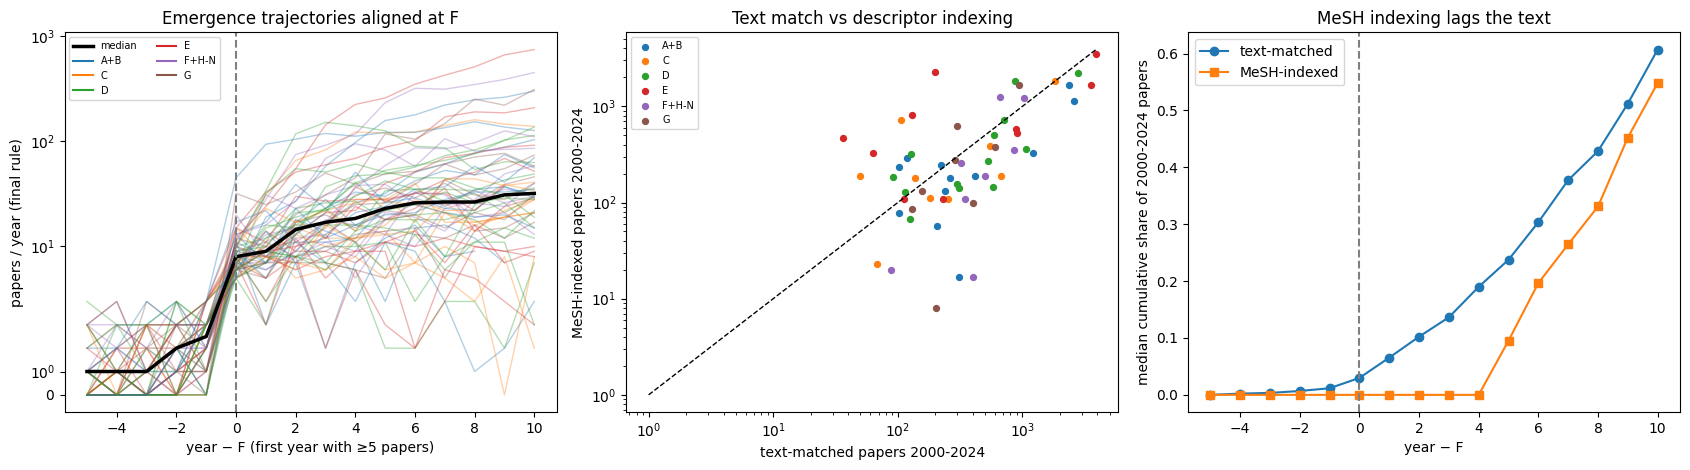

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
rel = np.arange(-5, 11)                                  # years relative to F
cols = {b: c for b, c in zip(sorted(df.branch.unique()), plt.cm.tab10.colors)}
aligned = []
for _, r in df.iterrows():
    yrs = np.arange(2000, 2025) - r.F
    s = np.array([r._final[yrs == k][0] if (yrs == k).any() else np.nan for k in rel], dtype=float)
    aligned.append(s)
    axes[0].plot(rel, s, color=cols[r.branch], alpha=0.35, lw=1)
axes[0].plot(rel, np.nanmedian(np.array(aligned), axis=0), color="k", lw=2.5, label="median")
axes[0].axvline(0, ls="--", color="grey"); axes[0].set_yscale("symlog", linthresh=5)
axes[0].set_xlabel("year − F (first year with ≥5 papers)"); axes[0].set_ylabel("papers / year (final rule)")
axes[0].set_title("Emergence trajectories aligned at F")
for b, c in cols.items(): axes[0].plot([], [], color=c, label=b)
axes[0].legend(fontsize=7, ncol=2)

for b, g in df.groupby("branch"):
    axes[1].scatter(g.total_textmatch, g.total_mesh_indexed, s=18, color=cols[b], label=b)
m = max(df.total_textmatch.max(), df.total_mesh_indexed.max())
axes[1].plot([1, m], [1, m], "k--", lw=1); axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("text-matched papers 2000-2024"); axes[1].set_ylabel("MeSH-indexed papers 2000-2024")
axes[1].set_title("Text match vs descriptor indexing"); axes[1].legend(fontsize=7)

cum_t, cum_m = [], []
for _, r in df.iterrows():
    yrs = np.arange(2000, 2025) - r.F
    for arr, acc in ((r._text, cum_t), (r._mesh, cum_m)):
        tot = arr.sum()
        c = np.cumsum(arr) / tot if tot else np.full(len(arr), np.nan)
        acc.append([c[yrs <= k][-1] if (yrs <= k).any() else 0.0 for k in rel])
axes[2].plot(rel, np.nanmedian(cum_t, axis=0), marker="o", label="text-matched")
axes[2].plot(rel, np.nanmedian(cum_m, axis=0), marker="s", label="MeSH-indexed")
axes[2].axvline(0, ls="--", color="grey"); axes[2].set_xlabel("year − F"); axes[2].set_ylabel("median cumulative share of 2000-2024 papers")
axes[2].set_title("MeSH indexing lags the text"); axes[2].legend()
plt.tight_layout(); plt.show()